# LTEE Re-Analysis

Analysis of mutation target diversity over time in six nonmutator populations
from Lenski's Long-Term Evolution Experiment (LTEE).

**Data**: Good et al. (2017) *Nature* 551:45–50.  
**Repository**: https://github.com/benjaminhgood/LTEE-metagenomic

## Prerequisites

This notebook requires the LTEE metagenomic data from Good et al. (2017).

1. Download the repository ZIP from https://github.com/benjaminhgood/LTEE-metagenomic
2. Unzip and place the resulting `LTEE-metagenomic-master` folder at `LTEE_analysis/LTEE-metagenomic-master/` (one level above this notebook).

Alternatively, update `LTEE_REPO_PATH` in the Setup cell to point to your local copy.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

LTEE_REPO_PATH = Path('../LTEE-metagenomic-master')
LTEE_DATA_PATH = LTEE_REPO_PATH / 'data_files'

NONMUTATOR_POPULATIONS = ['m5', 'm6', 'p1', 'p2', 'p4', 'p5']
T_STAR = 17500

# Colors for early/late distinction
c_early = '#0077BB'
c_late = '#EE7733'

## 2. Data Loading

For each population, mutations with `PASS` status are extracted and non-coding mutations excluded. Appearance times are taken from the HMM state trajectories as the first timepoint at which each mutation reaches detectable frequency.

In [2]:
def load_hmm_states(population):
    filepath = LTEE_DATA_PATH / f'{population}_well_mixed_state_timecourse.txt'
    with open(filepath, 'r') as f:
        lines = f.readlines()
    timepoints = [int(float(x)) for x in lines[0].strip().split(', ')]
    states = []
    for line in lines[5:]:
        vals = [int(float(x)) for x in line.strip().rstrip(',').split(', ') if x]
        states.append(vals)
    return timepoints, states

def get_appearance_time(state_trajectory, timepoints):
    for i, state in enumerate(state_trajectory):
        if state > 0:
            return timepoints[i]
    return None

def build_mutation_table(populations):
    all_data = []
    for pop in populations:
        filepath = LTEE_DATA_PATH / f'{pop}_annotated_timecourse.txt'
        full_df = pd.read_csv(filepath, header=0)
        full_df.columns = full_df.columns.str.strip()
        full_df['Passed?'] = full_df['Passed?'].str.strip()
        # The well_mixed_state_timecourse file has one row per PASS mutation,
        # in the same order as the PASS-filtered rows of the annotated file.
        # reset_index gives sequential i=0,1,2,... that correctly indexes states[i].
        pass_df = full_df[full_df['Passed?'] == 'PASS'].reset_index(drop=True)
        timepoints, states = load_hmm_states(pop)

        for i, row in pass_df.iterrows():
            if i >= len(states):
                continue
            all_data.append({
                'population': pop,
                'position': row['Position'],
                'gene': row['Gene'].strip() if isinstance(row['Gene'], str) else row['Gene'],
                'annotation': row['Annotation'].strip() if isinstance(row['Annotation'], str) else row['Annotation'],
                'appearance_time': get_appearance_time(states[i], timepoints)
            })
    return pd.DataFrame(all_data)

def simpson_d(labels):
    counts = pd.Series(labels).value_counts()
    proportions = counts / counts.sum()
    return (proportions ** 2).sum()

# Load data; exclude intergenic mutations - no unambiguous gene assignment
master_df = build_mutation_table(NONMUTATOR_POPULATIONS)
df = master_df[master_df['gene'] != 'intergenic'].copy()
print(f"Total genic mutations: {len(df)}")

Total genic mutations: 1464


## 3. Multi-Hit Gene Identification

Gene sets are computed for multiplicity thresholds m ≥ 2, 3, 4, pooling counts across all six populations.

In [3]:
# Count total mutations per gene across all populations
gene_counts = df['gene'].value_counts()

# Build datasets for each multiplicity threshold
multihit = {}
for m in [2, 3, 4]:
    genes = set(gene_counts[gene_counts >= m].index)
    df_m  = df[df['gene'].isin(genes)].copy()
    multihit[m] = {'genes': genes, 'df': df_m}
    print(f"m >= {m}: {len(genes)} genes, {len(df_m)} mutations ({len(df_m)/len(df):.1%} of all genic)")

# Keep m>=3 as primary for reference
multihit_genes = multihit[3]['genes']
df_mh = multihit[3]['df']
print(f"\nPrimary dataset (m>=3): {len(df_mh)} mutations in {len(multihit_genes)} genes")

m >= 2: 262 genes, 902 mutations (61.6% of all genic)
m >= 3: 121 genes, 620 mutations (42.3% of all genic)
m >= 4: 78 genes, 491 mutations (33.5% of all genic)

Primary dataset (m>=3): 620 mutations in 121 genes


## 4. Sliding Window Analysis

Windows of 10,000 generations, stepped by 2,500 generations. Simpson's concentration index $D = \sum_i p_i^2$ is computed within each window, where $p_i$ is the fraction of mutations in gene $i$.

In [4]:
window_size = 10000
step_size   = 2500

def compute_windows(data, min_count=20):
    """Compute Simpson's D in sliding windows over appearance time."""
    max_time = int(data['appearance_time'].max())
    results = []
    for t_start in np.arange(0, max_time - window_size + step_size, step_size):
        t_end    = t_start + window_size
        t_center = t_start + window_size / 2
        w = data[(data['appearance_time'] > t_start) & (data['appearance_time'] <= t_end)]
        if len(w) >= min_count:
            results.append({
                't_center': t_center,
                'n': len(w),
                'D_gene': simpson_d(w['gene'])
            })
    return pd.DataFrame(results)

window_df = compute_windows(df)
print(f"All genes: {len(window_df)} windows")

window_dfs_mh = {}
for m in [2, 3, 4]:
    wdf = compute_windows(multihit[m]['df'])
    window_dfs_mh[m] = wdf
    print(f"m >= {m}: {len(wdf)} windows")

All genes: 22 windows
m >= 2: 21 windows
m >= 3: 21 windows
m >= 4: 21 windows


## 5. Rarefaction

To control for unequal mutation counts across windows, each window is subsampled without replacement to $n_\mathrm{sub}$ mutations (the minimum count across qualifying windows). Bootstrap resampling is repeated 2,000 times per window to obtain 95% confidence intervals on $1/D$.

In [5]:
n_bootstrap = 2000

def rarefied_windows(data, window_df, n_subsample, label=''):
    """Bootstrap-rarefied 1/D in sliding windows."""
    print(f"Rarefaction [{label}]: subsampling to n={n_subsample} per window")
    results = []
    np.random.seed(42)
    max_time = int(data['appearance_time'].max())
    for t_start in np.arange(0, max_time - window_size + step_size, step_size):
        t_end    = t_start + window_size
        t_center = t_start + window_size / 2
        w = data[(data['appearance_time'] > t_start) & (data['appearance_time'] <= t_end)]
        if len(w) >= n_subsample:
            d_samples = []
            for _ in range(n_bootstrap):
                sub = w.sample(n=n_subsample, replace=False)
                d_samples.append(simpson_d(sub['gene']))
            results.append({
                't_center':   t_center,
                'n_original': len(w),
                'D_mean':     np.mean(d_samples),
                'D_lo':       np.percentile(d_samples, 2.5),
                'D_hi':       np.percentile(d_samples, 97.5),
            })
    return pd.DataFrame(results)

# All genes
n_sub_all = int(window_df['n'].min())
rare_all = rarefied_windows(df, window_df, n_sub_all, label='all genes')
print(f"All genes: {len(rare_all)} windows, n_subsample={n_sub_all}")

# Multi-hit: one rarefied dataset per threshold
rare_mh = {}
n_sub_mh = {}
for m in [2, 3, 4]:
    n_sub = int(window_dfs_mh[m]['n'].min())
    rare_mh[m] = rarefied_windows(multihit[m]['df'], window_dfs_mh[m], n_sub,
                                   label=f'm>={m}')
    n_sub_mh[m] = n_sub
    print(f"m >= {m}: {len(rare_mh[m])} windows, n_subsample={n_sub}")

Rarefaction [all genes]: subsampling to n=104 per window
All genes: 22 windows, n_subsample=104
Rarefaction [m>=2]: subsampling to n=70 per window
m >= 2: 21 windows, n_subsample=70
Rarefaction [m>=3]: subsampling to n=44 per window
m >= 3: 21 windows, n_subsample=44
Rarefaction [m>=4]: subsampling to n=34 per window
m >= 4: 21 windows, n_subsample=34


## 6. Early/Late Epoch Split

Early epoch: $t \leq t^* = 17{,}500$ generations. The late epoch is defined as the shortest terminal interval containing at least as many mutations as the early epoch, searched in steps of 500 generations.

In [6]:
T_STAR = 17500
max_time = int(df['appearance_time'].max())

early = df[df['appearance_time'] <= T_STAR].copy()
target_n = len(early)

# Find shortest late window ending at max_time with >= target_n mutations
for t_start in range(max_time, 0, -500):
    late_candidate = df[df['appearance_time'] > t_start]
    if len(late_candidate) >= target_n:
        T_LATE_START = t_start
        late = late_candidate.copy()
        break

print(f"Early (t <= {T_STAR}): {len(early)} mutations")
print(f"Late  (t > {T_LATE_START}): {len(late)} mutations")
print(f"Late window length: {max_time - T_LATE_START} generations")
print(f"Max appearance time: {max_time}")

Early (t <= 17500): 472 mutations
Late  (t > 35000): 476 mutations
Late window length: 25500 generations
Max appearance time: 60500


## 7. Figure 6

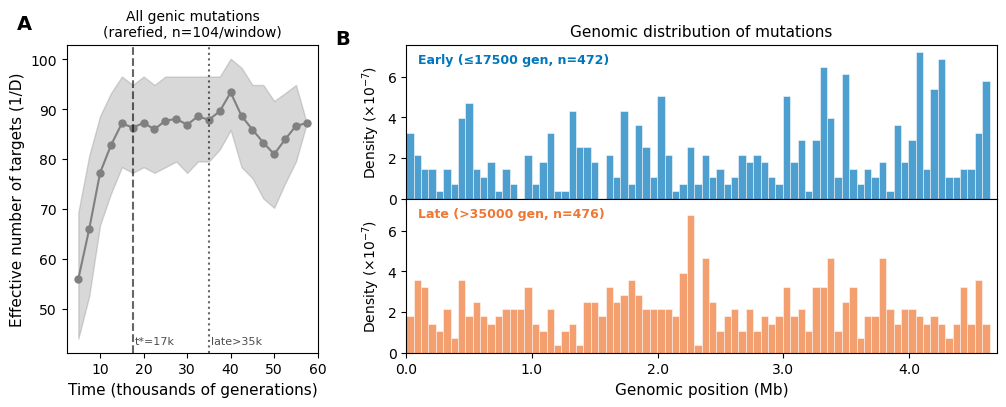

Saved figure6_ltee.pdf


In [7]:
fig = plt.figure(figsize=(12, 4))
gs = fig.add_gridspec(1, 3, wspace=0.35)
ax_A = fig.add_subplot(gs[0])
gs_C = gs[1:].subgridspec(2, 1, hspace=0)
ax_C = fig.add_subplot(gs_C[0])
ax_D = fig.add_subplot(gs_C[1], sharex=ax_C, sharey=ax_C)
t = rare_all['t_center'] / 1000
inv_mean = 1.0 / rare_all['D_mean']
inv_lo   = 1.0 / rare_all['D_hi']
inv_hi   = 1.0 / rare_all['D_lo']
ax_A.fill_between(t, inv_lo, inv_hi, color='gray', alpha=0.3)
ax_A.plot(t, inv_mean, 'o-', color='gray', markersize=5, linewidth=1.5)
ax_A.axvline(x=T_STAR / 1000, color='black', linestyle='--', alpha=0.6)
ax_A.axvline(x=T_LATE_START / 1000, color='black', linestyle=':', alpha=0.6)
ax_A.text(T_STAR / 1000 + 0.5, 0.02, f't*={T_STAR//1000}k',
          transform=ax_A.get_xaxis_transform(), fontsize=8, va='bottom', ha='left', alpha=0.7)
ax_A.text(T_LATE_START / 1000 + 0.5, 0.02, f'late>{T_LATE_START//1000}k',
          transform=ax_A.get_xaxis_transform(), fontsize=8, va='bottom', ha='left', alpha=0.7)
ax_A.set_xlabel('Time (thousands of generations)', fontsize=11)
ax_A.set_ylabel('Effective number of targets (1/D)', fontsize=11)
ax_A.set_title(f'All genic mutations\n(rarefied, n={n_sub_all}/window)', fontsize=10)
ax_A.text(-0.2, 1.1, 'A', transform=ax_A.transAxes, fontsize=14, fontweight='bold', va='top')
scale = 1e7
bins = np.linspace(0, 4.7e6, 81)
bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width   = bins[1] - bins[0]
counts_C, _ = np.histogram(early['position'], bins=bins, density=True)
counts_D, _ = np.histogram(late['position'],  bins=bins, density=True)
ax_C.bar(bin_centers, counts_C * scale, width=bin_width,
         color=c_early, alpha=0.7, edgecolor='white', linewidth=0.5)
ax_C.set_xlim(bins[0], bins[-1])
ax_C.set_ylabel(r'Density ($\times10^{-7}$)', fontsize=10)
ax_C.set_title('Genomic distribution of mutations', fontsize=11)
ax_C.text(0.02, 0.88, f'Early (≤{T_STAR} gen, n={len(early)})',
          transform=ax_C.transAxes, fontsize=9, color=c_early, fontweight='bold')
ax_C.text(-0.12, 1.1, 'B', transform=ax_C.transAxes, fontsize=14, fontweight='bold', va='top')
plt.setp(ax_C.get_xticklabels(), visible=False)
ax_D.bar(bin_centers, counts_D * scale, width=bin_width,
         color=c_late, alpha=0.7, edgecolor='white', linewidth=0.5)
ax_D.set_xlabel('Genomic position (Mb)', fontsize=11)
ax_D.set_ylabel(r'Density ($\times10^{-7}$)', fontsize=10)
ax_D.text(0.02, 0.88, f'Late (>{T_LATE_START} gen, n={len(late)})',
          transform=ax_D.transAxes, fontsize=9, color=c_late, fontweight='bold')
ax_D.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}'))
plt.savefig('figure6_ltee.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved figure6_ltee.pdf")

## 8. Supplementary Figure: Multi-Hit Sensitivity

Effective number of gene targets for m ≥ 2, 3, 4, plotted together to assess sensitivity to the multiplicity threshold.

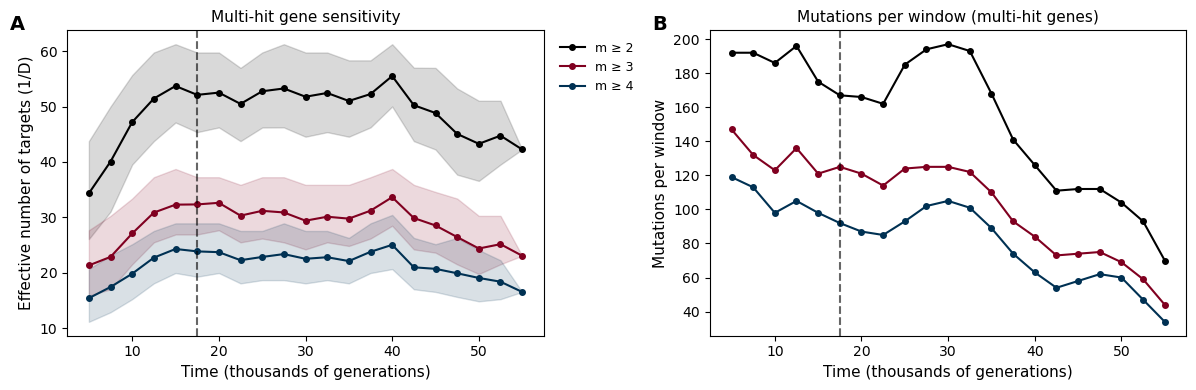

Saved supp_figure_multihit.pdf


In [8]:
colors = {2: '#000000', 3: '#800020', 4: '#003153'}
labels = {m: f'm ≥ {m}' for m in [2, 3, 4]}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax, ax_n = axes

for m in [2, 3, 4]:
    rd = rare_mh[m]
    t        = rd['t_center'] / 1000
    inv_mean = 1.0 / rd['D_mean']
    inv_lo   = 1.0 / rd['D_hi']
    inv_hi   = 1.0 / rd['D_lo']
    ax.fill_between(t, inv_lo, inv_hi, color=colors[m], alpha=0.15)
    ax.plot(t, inv_mean, 'o-', color=colors[m], markersize=4,
            linewidth=1.5, label=labels[m])

ax.axvline(x=T_STAR / 1000, color='black', linestyle='--', alpha=0.6)
ax.set_xlabel('Time (thousands of generations)', fontsize=11)
ax.set_ylabel('Effective number of targets (1/D)', fontsize=11)
ax.set_title('Multi-hit gene sensitivity', fontsize=11)
ax.legend(fontsize=9, frameon=False, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.text(-0.12, 1.05, 'A', transform=ax.transAxes, fontsize=14, fontweight='bold', va='top')

for m in [2, 3, 4]:
    wdf = window_dfs_mh[m]
    ax_n.plot(wdf['t_center'] / 1000, wdf['n'], 'o-', color=colors[m],
              markersize=4, linewidth=1.5, label=labels[m])

ax_n.axvline(x=T_STAR / 1000, color='black', linestyle='--', alpha=0.6)
ax_n.set_xlabel('Time (thousands of generations)', fontsize=11)
ax_n.set_ylabel('Mutations per window', fontsize=11)
ax_n.set_title('Mutations per window (multi-hit genes)', fontsize=11)
ax_n.text(-0.12, 1.05, 'B', transform=ax_n.transAxes, fontsize=14, fontweight='bold', va='top')

plt.tight_layout()
plt.savefig('supp_figure_multihit.pdf', dpi=300, bbox_inches='tight')
plt.show()
print("Saved supp_figure_multihit.pdf")